<a href="https://colab.research.google.com/github/LSim2002/deep-hedging/blob/main/Part%201%3A%20FFN%20vs%20Black%E2%80%93Scholes%20under%20transaction%20costs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Option and Hedging

Option seller (usually a bank/market maker) sells the **right** to buy (_call_ option) or to sell (_put_ option) an _underlying_ (ex: a stock) at a **fixed** price (_strike_ price), by the _expiry date_.

Buying an option costs a _premium_ (paid upfront - also called "option price").


* Call option:
    * buyer profits if stock price > strike price
    * seller profits if stock price < strike price
* Put option:
    * buyer profits if stock price < strike price
    * seller profits if stock price > strike price

To offset risks from the sold option, seller will continuously buy/sell the underlying. That's what Hedging is. He holds a qty of the underlying that changes with time.
* If seller sells call option: he will long (buy, sell at higher) stocks to protect himself from price upwards.
* If seller sells put option: he will short (borrow, sell, rebuy at lower, give back borrowed) to protect himself from price downwards.


# Wiener process / Brownian motion $W_t$


(memories from math class)

Continuous-time random process with these defining properties:
- $W_0 = 0$
- Independent increments: changes in $W$ are independent of each other.
- $W_t - W_s \sim \mathcal{N}(0, t-s)$ — increments are normally distributed with mean 0 and variance equal to the elapsed time. $dW_t \sim \mathcal{N}(0, dt)$
- Continuous , but nowhere differentiable (infinitely jagged when dt->0).


# Geometric Brownian Motion and $S_t$ given assumptions








If you modeled the stock price itself as plain Brownian motion ($dS_t = \mu\, dt + \sigma\, dW_t$)

* Price could go negative
* Movements need to be scaled to stock price

So what we model as a Brownian-motion-driven process is the *relative* (geometric / percentage) change:

$$
\frac{dS_t}{S_t} = \mu\, dt + \sigma\, dW_t
$$

So this equation says: the percentage return over an infinitesimal time step has a deterministic drift component $\mu\, dt$ (the expected return) plus a random shock $\sigma\, dW_t$ (volatility scaling a Brownian increment)

Which gives:

$$
dS_t = \mu S_t\, dt + \sigma S_t\, dW_t \tag{1}
$$

The *absolute* size of price moves scales with the current price — solving the issue above.


**Itô's lemma** to derive the closed-form solution for $S_t$

Direct application of Ito's lemma on $\ln S_t$ yields



$$
S_t = S_0 \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]
$$

We can now simulate synthetic price paths for training/testing hedging strategies.


**Note:** the drift term became $\mu - \sigma^2/2$, not just $\mu$ — this $-\sigma^2/2$ correction is sometimes called "Itô's correction" or the "volatility drag," and it's a direct consequence of the extra second-derivative term in Itô's lemma.

# Option pricing and hedging with B&S

### 1. Assumptions
As seen right before, we place ourselves under a set of simplifying assumptions:
- The underlying stock price $S_t$ follows a **Geometric Brownian Motion**:
$$
dS_t = \mu S_t \, dt + \sigma S_t \, dW_t \tag{1}
$$
where $\mu$ is the drift (expected return), $\sigma$ is the (constant) volatility
- No transaction costs.
- Trading is continuous (you can rebalance any instant).
- Constant, known risk-free interest rate $r$.
- The option is **European** (can only be exercised at expiry $T$, not before).

### 2. Ito's lemma on V(S,t)
Let $V(S, t)$ denote the price (premium) of the option at time $t$, given the current stock price $S$. Strike price, vol, interest rate are considered **fixed** through time. This enables us to write $V$ as a function of S and t only and use Ito's lemma. (This is why B&S is imperfect in practice).


Under these assumptions, we can use Itô's lemma on $V(S, t)$:

$$
dV = \left(\frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right)dt + \sigma S \frac{\partial V}{\partial S}\,dW_t \tag{2}
$$


### 3. Build a hedging portfolio with forced returns to apply no-arbitrage


We want to apply no-arbitrage (force the portfolio's return to be $r$) → for that we need it deterministic (riskless).

We construct a portfolio $\Pi$: buy (long) 1 option at premium price $V$, borrow (short) $\Delta$ shares of stock. I.e we're hedging using $\Delta$:

$$
\Pi = V - \Delta S
$$


(Note: The sign/magnitude of $\Delta$ that comes out depends on the option's specific payoff — call vs. put — only once we plug in the boundary condition later. The "long option / short stock" convention above is just one of two equally valid mirror-image setups.)


Since $\Delta$ is constant over $dt$ by construction (it is the number of shares held at time $t$, fixed until $t+dt$):
$$
d\Pi = dV - \Delta\, dS \quad
$$
Using the $dV$ and $dS$ formulas ($(1)$ and $(2)$):

$$
d\Pi = \left(\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2V}{\partial S^2}\right)dt + \sigma S\frac{\partial V}{\partial S}\,dW_t - \Delta \sigma S\, dW_t
$$

**If we use $\Delta = \frac{\partial V}{\partial S}$**, the two $dW_t$ terms **exactly cancel**:

$$
d\Pi = \left(\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2V}{\partial S^2}\right)dt \tag{3}
$$

Making the portfolio fully deterministic, i.e zero variance over the next instant which is exactly what **"risk-free"** means in this context.

Enforcing no-arbitrage yields:

$$
d\Pi = r\Pi\, dt = r(V - \Delta S)\,dt \tag{4}
$$


## 4. B&S PDE
Equating expressions for $d\Pi$ ($(3)$ and $(4)$) yields the **Black-Scholes PDE**:

$$
\left(\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2V}{\partial S^2}\right)dt = r\left(V - S\frac{\partial V}{\partial S}\right)dt
$$

Rearranging:

$$
\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS\frac{\partial V}{\partial S} - rV = 0 \tag{5}
$$

Notably, $\mu$ has disappeared entirely — the option's fair price depends only on volatility and the risk-free rate (both supposedly constant).

(Intuition: any "extra return expectation" is already canceled by the hedge — the replicating portfolio makes you indifferent to direction.)

## 5. Solving B&S PDE to get closed formula for option pricing and hedging

$(5)$ is now a deterministic PDE, solvable with a boundary condition given by the option's payoff at expiry. For a **call**: $V(S,T) = \max(S-K,0)$, where $K$ is the strike price. Solving the PDE (via a change of variables transforming it into the standard heat equation, I won't do it here) gives the closed-form solution labeled $C$ for a call. (It is the same $V(S,t)$, just specialized to the call boundary condition).

$$
C(S,t) = S\,N(d_1) - Ke^{-r(T-t)}N(d_2) \tag{6}
$$

where:

$$
d_1 = \frac{\ln(S/K) + \left(r + \frac{\sigma^2}{2}\right)(T-t)}{\sigma \sqrt{T-t}}, \qquad
d_2 = d_1 - \sigma \sqrt{T-t} \tag{7}
$$


Also, we can now compute delta:

$$
\Delta_{\text{call}} = \frac{\partial V}{\partial S} = \frac{\partial C}{\partial S} = N(d_1)
$$

---

For a **put** option, the boundary condition at expiry is different from the call:

$$
V(S, T) = \max(K - S, 0)
$$

Solving the B&S PDE with this boundary condition gives:

$$
P(S, t) = K e^{-r(T-t)} N(-d_2) - S\, N(-d_1)  \tag{8}
$$

with the same $d_1$, $d_2$ as before. Delta for the put:

$$
\Delta_{\text{put}} = \frac{\partial P}{\partial S} = N(d_1) - 1  \tag{9}
$$

Note $\Delta_{\text{put}} \in [-1, 0]$ — always negative, consistent with the earlier intuition: hedging a short put requires shorting stock (or equivalently, holding a negative quantity of stock), since the put seller's liability grows when the price falls.




## 6. Conclusion: What Black-Scholes gives us

Under the following assumptions:
- The underlying stock price follows a Geometric Brownian Motion with **constant volatility** $\sigma$
- **Constant, known risk-free rate** $r$
- No transaction costs, continuous trading, no arbitrage

Black-Scholes provides two things:

1. **A closed-form option pricing formula** $C(S,t)$ (or $P(S,t)$ for a put) — the fair price of the option at any time $t$, as a function of
    * current stock price $S$,
    * strike $K$,
    * time to expiry $T-t$,
    * volatility $\sigma$,
    * risk-free rate $r$.

2. **A closed-form hedge ratio (delta)** $\Delta = N(d_1)$ — the exact quantity of stock to hold at each instant to make the hedged portfolio riskless and arbitrage-free, derived directly from the pricing formula as $\Delta = \partial V / \partial S$.

These two outputs are not independent: delta is a byproduct of the pricing formula, obtained by differentiating it with respect to $S$. The pricing formula is the primary result; delta follows from it.

# The Deep Hedging Project


### Goal

Learn a deep hedging policy that minimizes CVaR of total P&L instead of using the closed-form B&S delta, which is theoretically optimal only in a **frictionless, constant-vol, continuous-trading world**.
:

$$
\Delta_t = f_\theta(x_t), \quad x_t = \left(\frac{S_t}{K} ,\; T-t,\; \Delta_{t-1}\right)
$$



Both B&S and deep hedger performances will be evaluated on synthetic GBM data. Since GBM is Markovian, a feedforward network (FFN) is what we will use. To account for the transaction costs, previous outputted delta will be given as an input, making it a sort of "semi" recurrent network (not recurrent by architecture - a hidden state/cell state of an lstm would serve no purpose in markovian environments).

Expected results:

- **Without transaction costs:** FFN ≈ B&S. confirms **FFN is able to approximate the optimal B&S delta function.**

- **With transaction costs:** FFN > B&S by **balancing hedging accuracy and transaction costs** (main result).





### Important nuance
This isn't a fully fair comparison — B&S was never designed for a world with frictions. The claim isn't "the RNN is mathematically smarter than B&S." It's: **the RNN is optimized for the actual problem (hedging with frictions in non-GBM price paths), which B&S wasn't designed for.**

#Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm #to get N(d1)
import torch
import torch.nn as nn
from scipy.stats import norm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Step 1: Simulate GBM Price Paths function


- Implement `simulate_gbm(S0, mu, sigma, T, n_steps, n_paths)`
- Returns array of shape `(n_paths, n_steps+1)` — N simulated paths
- Use the closed-form solution:
$$S_{t+\Delta t} = S_t \exp\left[\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\, Z\right], \quad Z \sim \mathcal{N}(0,1)$$


**Note: Why we use the closed-form solution instead of the differential form**

One could naively discretize the GBM SDE directly equation (1) (Euler-Maruyama):

$$S_{t+\Delta t} = S_t + \mu S_t \Delta t + \sigma S_t \sqrt{\Delta t}\, Z, \quad Z \sim \mathcal{N}(0,1)$$

However, this is a first-order approximation that accumulates discretization error over many steps,
and can produce negative prices if the random shock is large enough.

The closed-form solution derived earlier is exact (no approximation error), always positive by construction, and no harder to implement — so there is no reason to use Euler-Maruyama here.

In [ ]:
def simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths, seed=None, eps=1e-8):
    #eps is to make sure the last t is not exactly T (to avoid division by zero when using T-t)
    # T is time to expiry (in years), mu and sigma are annualized -
    # (using years by convention - The only constraint is consistency: T, mu, sigma, and dt must all use the same time unit.)

    #Returns:
    #paths (shape (n_paths, n_steps+1))
    # and t (array of shape (n_steps+1,)) — time grid from 0 to T

    if seed is not None:
        np.random.seed(seed)

    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)  # time grid
    t[-1] = (1 - eps) * T  # nudge last point off T so tau = T - t never hits exactly 0 (to avoid division by zero)

    # sample standard normal increments: shape (n_paths, n_steps)
    Z = np.random.standard_normal((n_paths, n_steps))

    # closed-form GBM step: S_{t+dt} = S_t * exp((mu - sigma^2/2)*dt + sigma*sqrt(dt)*Z)
    log_increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    # cumulative sum of log increments to get log path, then exponentiate
    log_paths = np.concatenate(
        [np.zeros((n_paths, 1)), np.cumsum(log_increments, axis=1)],
        axis=1
    )

    paths = S0 * np.exp(log_paths)  # shape: (n_paths, n_steps+1)

    return paths, t

## Step 2: B&S Delta Hedging


In [ ]:
def get_bs_delta(S, K, r, sigma, tau):
    # S,r, sigma, tau can be a scalar, or 1d (1 path) or 2d (paths),
    # delta - same shape as S
    assert np.all(np.asarray(tau) > 0), "tau must be strictly positive (division by zero at expiry)" #this shouldnt happen but still safe to check

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    delta = norm.cdf(d1)


    return delta

In [ ]:
def bs_call_price(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

$$
\text{P&L} = X_0 \;-\; \max(S_T - K,\ 0) \;+\; \sum_{t} \Delta_t \, (S_{t+1} - S_t) \;-\; c \sum_{t} \left| \Delta_t - \Delta_{t-1} \right|
$$

where $X_0 = V_{\text{BS}}(0)$ is the Black–Scholes price of the call at inception — the premium collected for selling the option.

It's essentially:   **premium − payoff + trading gains − transaction costs.**


Note: Both hedgers are endowed with the same initial wealth X0 = V_BS(0), the Black–Scholes price of the option. The premium is not learned: this project isolates the hedging policy, so both strategies start from identical capital and differ only in how they trade.

In [ ]:
def compute_terminal_pnl(X0, S, deltas, K, c):
    #computes terminal pnl of given paths, when hedging with given delta paths
    # using P&L formula given above

    n_paths, n_steps_plus_1 = S.shape

    # trading gains: sum_t Delta_t * (S_{t+1} - S_t), t = 0 .. n_steps-1
    dS = np.diff(S, axis=1)                    # shape (n_paths, n_steps)
    delta_t = deltas[:, :-1]                    # Delta_t used to hedge over [t, t+1)
    trading_gains = np.sum(delta_t * dS, axis=1)

    # transaction costs: c * sum_t |Delta_t - Delta_{t-1}|, Delta_{-1} = 0
    delta_prev = np.concatenate([np.zeros((n_paths, 1)), delta_t[:, :-1]], axis=1)
    # shifted: Delta_{t-1} for t=0..n_steps-1, with Delta_{-1}=0 (we couldve also used np.roll)
    delta_diffs = np.abs(delta_t - delta_prev)
    transaction_costs = c * np.sum(delta_diffs, axis=1)

    # payoff at expiry (European call, ATM strike K)
    S_T = S[:, -1]
    payoff = np.maximum(S_T - K, 0.0)

    pnl = X0 -payoff + trading_gains - transaction_costs

    return pnl

In [ ]:
def compute_cvar(pnl, alpha):
    #Compute CVaR (scalar) (average pnl of the alpha percentile worst pnls of the P&L distribution at level alpha.)
    #pnl   : array (n_paths,) — terminal P&L per path
    #alpha : tail probability (e.g. 0.05 = worst 5%)
    var_threshold = np.quantile(pnl, alpha)      # VaR: alpha-quantile of P&L
    tail_mask = pnl <= var_threshold
    cvar = pnl[tail_mask].mean()

    return cvar

## Step 4: FFN delta hedging


In [ ]:
def train_val_test_split(S, val_frac=0.15, test_frac=0.15, seed=0):
    """
    Splits paths (not time steps) into train/val/test — each path is an
    independent sample, so this is a standard row-wise split.
    """
    rng = np.random.default_rng(seed)
    n_paths = S.shape[0]
    idx = rng.permutation(n_paths)

    n_val = int(n_paths * val_frac)
    n_test = int(n_paths * test_frac)

    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    return S[train_idx], S[val_idx], S[test_idx]

In [ ]:
class FFNPolicy(nn.Module):
    """
    Memoryless policy: same small MLP applied independently at every
    timestep. Input x_t = (S_t/K, tau_t, Delta_{t-1}).
    """
    def __init__(self, input_size=3, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x_t):
        return torch.sigmoid(self.net(x_t)).squeeze(-1)

In [ ]:
def rollout_ffn(model, X0, S, t, K, c_cost):
    """
    Sequentially applies the FFN at each step (Delta_{t-1} fed back in),
    computes terminal PnL. Fully differentiable.

    Args:
        model  : FFNPolicy
        S      : torch tensor (batch, n_steps+1)
        t      : torch tensor (n_steps+1,) — time grid, t[-1] < T (nudged)
        K      : strike (scalar)
        c_cost : proportional transaction cost rate

    Returns:
        pnl : torch tensor (batch,)
    """
    batch_size, n_steps_plus_1 = S.shape
    n_steps = n_steps_plus_1 - 1
    T = t[-1] / (1 - 1e-8)  # recover true T (t[-1] was nudged to (1-eps)*T)

    tau = (T - t).unsqueeze(0).expand(batch_size, -1)  # (batch, n_steps+1)
    moneyness = S / K

    delta_prev = torch.zeros(batch_size, device=S.device)
    trading_gains = torch.zeros(batch_size, device=S.device)
    cost_total = torch.zeros(batch_size, device=S.device)

    for i in range(n_steps):
        x_t = torch.stack([
            moneyness[:, i],
            tau[:, i],
            delta_prev,
        ], dim=-1)

        delta_t = model(x_t)

        dS = S[:, i + 1] - S[:, i]
        trading_gains += delta_t * dS
        cost_total = cost_total + c_cost * torch.abs(delta_t - delta_prev)

        delta_prev = delta_t

    payoff = torch.clamp(S[:, -1] - K, min=0.0)
    pnl = X0 -payoff + trading_gains - cost_total

    return pnl

In [ ]:
def cvar_loss(pnl, alpha):
    """
    Differentiable CVaR of PnL: mean of the worst alpha-fraction in the batch. (this is why we use torch topk insteead of numpy)
    """
    k = max(1, int(alpha * pnl.shape[0])) # max(1, ...) ensures we always select at least one path
    worst, _ = torch.topk(pnl, k, largest=False)
    return worst.mean()

In [ ]:
def train_ffn(S_train, X0, S_val, t, K, c_cost, alpha,
              epochs, batch_size, lr=1e-3, hidden_dim=32, seed=0):
    torch.manual_seed(seed)
    model = FFNPolicy(hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    S_train_t = torch.tensor(S_train, dtype=torch.float32, device=device)#S_train as tensor so S_train_t
    S_val_t = torch.tensor(S_val, dtype=torch.float32, device=device)
    t_t = torch.tensor(t, dtype=torch.float32, device=device)

    n_train = S_train_t.shape[0]

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_train, device=device)
        epoch_losses = []

        for start in range(0, n_train, batch_size):
            batch_idx = perm[start:start + batch_size]
            S_batch = S_train_t[batch_idx]

            pnl = rollout_ffn(model, X0, S_batch, t_t, K, c_cost)
            loss = -cvar_loss(pnl, alpha)  # maximize CVaR(PnL) == minimize -CVaR

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        scheduler.step()          # once per epoch

        if epoch == 0 or (epoch + 1) % 100 == 0: #print and run  inference on val only every 100 epochs
            model.eval()
            with torch.no_grad():
                pnl_val = rollout_ffn(model, X0, S_val_t, t_t, K, c_cost)
                val_cvar = cvar_loss(pnl_val, alpha).item()
            print(f"epoch {epoch+1:>3} | lr {scheduler.get_last_lr()[0]:.2e} | train CVaR loss {np.mean(epoch_losses):.4f} | val CVaR {val_cvar:.4f}")

    return model

In [ ]:
def plot_pnl_grid(pnl_results_dict, c_list, alpha=0.05, bins=100):
    n = len(c_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows), squeeze=False)

    for ax, c in zip(axes.ravel(), c_list):
        for label, color in [("B&S", "tab:blue"), ("FFN", "tab:orange")]:
            pnl = pnl_results_dict[f"{label} for c={c}"]
            cvar = compute_cvar(pnl, alpha)
            ax.hist(pnl, bins=bins, alpha=0.5, density=True, color=color,
                    label=f"{label}  CVaR={cvar:.4f}")
            ax.axvline(cvar, color=color, ls="--", lw=1.2)
        ax.axvline(0.0, color="k", lw=0.8)
        ax.set_title(f"c = {c}")
        ax.legend(fontsize=8)

    for ax in axes.ravel()[n:]:
        ax.axis("off")
    fig.suptitle("Terminal P&L distribution, B&S vs deep hedger, by transaction cost")
    fig.tight_layout()
    plt.show()

## Step 5: Run code and Compare

For different values of c:

- Plot P&L distributions (histogram) for both models
- Compare CVaR values


In [ ]:
#Parameters for part 1 - we use whats generaly used in deep hedging literature. The time we use is "year" for the same reason
S0    = 100.0
mu    = 0       # see note below
sigma = 0.2     # 20% annualized volatility
T     = 1.0     # 1 year to expiry
r     = 0       # see note below
K=S0

alpha=0.05

n_steps = 251#1004   # (251+1 for S0 = 252 trading days)
n_paths = 50000 # number of simulated paths


**On drift:** The drift is set to zero, following Bühler et al. (2018). This is not cosmetic: B&S delta is payoff-replication-optimal, not CVaR-optimal, and if the underlying carries a risk premium (μ > r) the network can improve its CVaR by overlaying a small directional bet on the hedge — beating B&S at zero transaction cost for reasons that have nothing to do with frictions. Setting μ = 0 removes that free lunch, so B&S is genuinely optimal at c = 0 and any gap that opens for c > 0 is attributable to transaction costs alone.


**On rates:** Rates are set to zero. The B&S price and delta assume a cash leg earning `r`; our P&L has no cash account, so it lives in an `r = 0` world. Pricing with `r > 0` while never earning that interest leaves an uncompensated carry. Adding the cash account would just add code — it accrues equally for both hedgers and leaves the gap untouched.

In [ ]:
X0 = bs_call_price(S0, K, r, sigma, T)
print(X0)

7.965567455405804


In [ ]:
gbm_price_paths, t = simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths, seed=42)
tau = T-t
print(f"gbm_price_paths shape: {gbm_price_paths.shape}")

gbm_price_paths shape: (50000, 252)


In [ ]:
gbm_price_paths_train, gbm_price_paths_val, gbm_price_paths_test = train_val_test_split(gbm_price_paths, val_frac=0.15, test_frac=0.15, seed=0)
#70% of price paths as train, 15% as val, and 15% as test

c = 0: B&S test — mean PnL: -0.0040 | CVaR 5%: -1.0106
epoch   1 | lr 1.00e-03 | train CVaR loss 15.8610 | val CVaR -14.7537
epoch 100 | lr 9.62e-04 | train CVaR loss 1.4542 | val CVaR -1.5159
epoch 200 | lr 8.54e-04 | train CVaR loss 1.1974 | val CVaR -1.1991
epoch 300 | lr 6.91e-04 | train CVaR loss 1.1133 | val CVaR -1.1254
epoch 400 | lr 5.00e-04 | train CVaR loss 1.1139 | val CVaR -1.0902
epoch 500 | lr 3.09e-04 | train CVaR loss 1.1066 | val CVaR -1.0755
epoch 600 | lr 1.46e-04 | train CVaR loss 1.0990 | val CVaR -1.0709
epoch 700 | lr 3.81e-05 | train CVaR loss 1.0954 | val CVaR -1.0675
epoch 800 | lr 0.00e+00 | train CVaR loss 1.0834 | val CVaR -1.0671
c = 0: FFN test — mean PnL: 0.0015 | CVaR 5%: -1.0528
c = 0.001: B&S test — mean PnL: -0.0095 | CVaR 5%: -1.0182
epoch   1 | lr 1.00e-03 | train CVaR loss 15.8617 | val CVaR -14.7544
epoch 100 | lr 9.62e-04 | train CVaR loss 1.4635 | val CVaR -1.4962
epoch 200 | lr 8.54e-04 | train CVaR loss 1.1942 | val CVaR -1.2000
epoch 300 | 

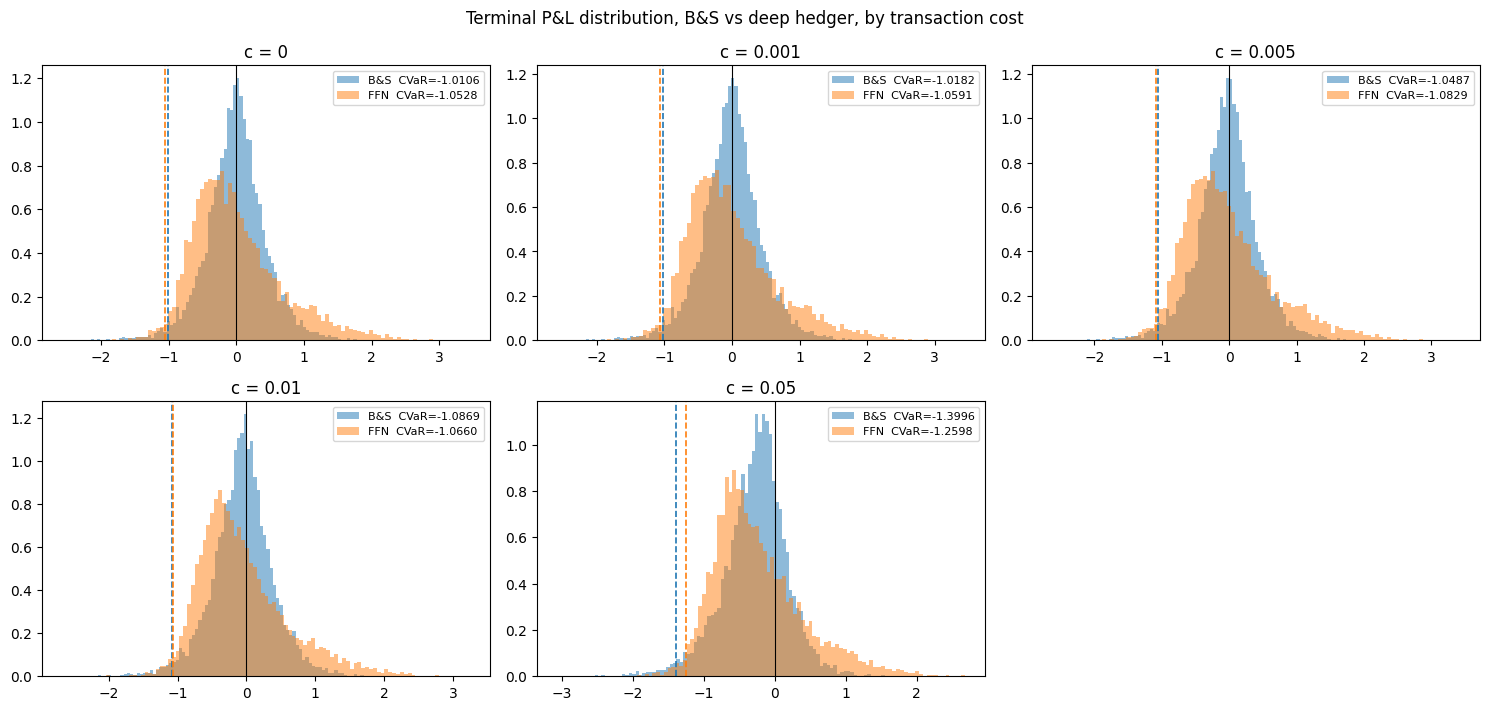

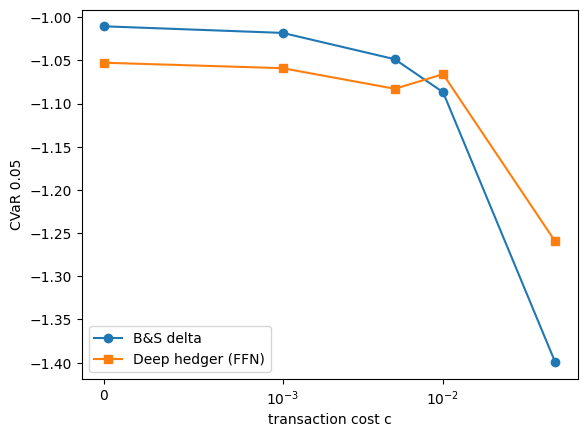

In [ ]:
c_list = [0, 0.001, 0.005, 0.01, 0.05]
pnl_results_dict = {}

bs_delta_paths_test = get_bs_delta(gbm_price_paths_test, K, r, sigma, tau)

for curr_c in c_list:
    # 1. get results for b&s
    curr_bs_pnls_test = compute_terminal_pnl(X0, gbm_price_paths_test, bs_delta_paths_test, K, curr_c)
    pnl_results_dict[f"B&S for c={curr_c}"] = curr_bs_pnls_test

    bs_cvar_test = compute_cvar(curr_bs_pnls_test, alpha)
    print(f"c = {curr_c}: B&S test — mean PnL: {curr_bs_pnls_test.mean():.4f} | CVaR 5%: {bs_cvar_test:.4f}")

    #2. get results for FFN
    ffn = train_ffn(gbm_price_paths_train, X0, gbm_price_paths_val, t, K, curr_c, alpha, epochs=800, batch_size=2048,lr=1e-3)
    S_test_t = torch.tensor(gbm_price_paths_test, dtype=torch.float32, device=device)
    t_t = torch.tensor(t, dtype=torch.float32, device=device)
    with torch.no_grad():
        curr_pnl_ffn_test = rollout_ffn(ffn, X0, S_test_t, t_t, K, curr_c).cpu().numpy()
    pnl_results_dict[f"FFN for c={curr_c}"] = curr_pnl_ffn_test
    curr_ffn_cvar_test = compute_cvar(curr_pnl_ffn_test, alpha)

    print(f"c = {curr_c}: FFN test — mean PnL: {curr_pnl_ffn_test.mean():.4f} | CVaR 5%: {curr_ffn_cvar_test:.4f}")

plot_pnl_grid(pnl_results_dict, c_list, alpha=alpha, bins=100)

bs_cvars  = [compute_cvar(pnl_results_dict[f"B&S for c={c}"], alpha) for c in c_list]
ffn_cvars = [compute_cvar(pnl_results_dict[f"FFN for c={c}"], alpha) for c in c_list]
plt.plot(c_list, bs_cvars, "o-", label="B&S delta")
plt.plot(c_list, ffn_cvars, "s-", label="Deep hedger (FFN)")
plt.xscale("symlog", linthresh=1e-3)
plt.xlabel("transaction cost c"); plt.ylabel(f"CVaR {alpha}"); plt.legend()
plt.show()

**About B&S when c=0:**

At c = 0 the B&S hedge is not exactly replicating, since rebalancing is discrete. The residual CVaR scales as 1/√n: quadrupling the rebalancing frequency (251 → 1004 steps) halves it (1.011 → 0.506), confirming the residual is discretization error rather than a defect in the hedge or the P&L accounting

# End note

The purpose of this project was to demonstrate that once transaction costs are non-zero (and increasingly so as they grow) a deep hedger outperforms Black-Scholes delta hedging. Nothing here is about raw model performance, computational efficiency, or architectural sophistication; the FFN is a vehicle for a single point, not an object of study in itself.

Through this project, we have shown that:
1. Under GBM assumptions, a deep hedging model minimizing CVaR of terminal P&L is able to closely match the optimal B&S delta strategy.
2. Once transaction costs are introduced, B&S becomes suboptimal, while the deep hedger FFN, by taking its previous hedge position as an input, can learn to trade off hedging accuracy against transaction costs, achieving a lower CVaR.

Extensions of this project could include:


1. Testing on real market data: both B&S and the deep hedger's performance are expected to degrade, since volatility and drift are not constant in practice. More expressive architectures with memory, such as LSTMs or Transformers, could potentially exploit the resulting non-Markovian structure to recover some of that lost performance.

2. Extend to path-dependent or exotic payoffs (e.g. Asian, barrier options), where the optimal hedge itself is no longer available in closed form, and deep hedging's model-free nature becomes a genuine advantage rather than just a cost-aware refinement.

3. Test architecture scaling laws — does hedging performance saturate with network size, or does a larger FFN keep improving?